# Lab: Estimation and Visualization of Q-Table Convergence in a Markov Decision Process using Q-Learning

## Theory

A Markov Decision Process (MDP) is a mathematical framework used to model sequential decision-making problems in which outcomes are partly random and partly under the control of a decision-making agent. An MDP is formally defined by a tuple (S, A, P, R, gamma), where S is the set of states, A is the set of actions, P is the state-transition probability function, R is the reward function, and gamma is a discount factor between 0 and 1 that determines the importance of future rewards.

The Markov property states that the future state of the system depends only on the current state and action, and not on the sequence of events that preceded it. This property makes MDPs tractable to analyze and solve using dynamic programming and reinforcement learning techniques.

Q-Learning is a model-free reinforcement learning algorithm used to find the optimal action-selection policy for a given MDP. It works by learning an action-value function, Q(s, a), which estimates the expected cumulative future reward of taking action a in state s and following the optimal policy thereafter. The Q-values are stored in a table (the Q-table), with one entry for every state-action pair.

The Q-table is updated iteratively using the Bellman equation:

Q(s, a) <- Q(s, a) + alpha * [ r + gamma * max_a' Q(s', a') - Q(s, a) ]

where:

* alpha = learning rate, controlling how much new information overrides old information
* gamma = discount factor, controlling the importance of future rewards
* r = immediate reward received after taking action a in state s
* s' = next state reached after taking action a
* max_a' Q(s', a') = the maximum estimated future reward achievable from the next state

During training, the agent balances exploration and exploitation using an epsilon-greedy policy: with probability epsilon it selects a random action (exploration), and with probability 1 - epsilon it selects the action with the highest current Q-value (exploitation). Epsilon is typically decayed over time so that the agent explores more early in training and exploits its learned knowledge later.

As training progresses, the Q-values propagate backward from states with high reward (such as a goal state) toward earlier states, gradually forming an estimate of the optimal policy. Rather than examining only the final, fully converged Q-table, it is instructive to record and visualize the Q-table at multiple points during training. This reveals how value information spreads through the state space over time and provides insight into the convergence behavior of the algorithm.

In this experiment, a Q-learning agent is trained on a 5x5 grid-world MDP. The agent must navigate from a fixed start state to a goal state while avoiding an obstacle state, using the four possible actions: up, down, left, and right. The Q-table is sampled at regular intervals throughout training, and the sequence of snapshots is visualized to illustrate the convergence process.

## Program Codes:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize

get_ipython().run_line_magic('matplotlib', 'inline')

# ----------------------------------------------------------------------------
# 1. Define the environment (a simple grid-world Markov Decision Process)
# ----------------------------------------------------------------------------
GRID_SIZE = 5
N_STATES = GRID_SIZE * GRID_SIZE
N_ACTIONS = 4  # 0=up, 1=down, 2=left, 3=right
ACTION_DELTAS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}

START_STATE = (0, 0)
GOAL_STATE = (GRID_SIZE - 1, GRID_SIZE - 1)
OBSTACLE_STATE = (2, 2)

def state_to_idx(pos):
    r, c = pos
    return r * GRID_SIZE + c

def step(pos, action):
    """Apply an action to a position, respecting grid boundaries."""
    dr, dc = ACTION_DELTAS[action]
    r, c = pos[0] + dr, pos[1] + dc
    r = max(0, min(GRID_SIZE - 1, r))
    c = max(0, min(GRID_SIZE - 1, c))
    new_pos = (r, c)

    if new_pos == GOAL_STATE:
        reward, done = 10.0, True
    elif new_pos == OBSTACLE_STATE:
        reward, done = -10.0, True
    else:
        reward, done = -1.0, False

    return new_pos, reward, done

# ----------------------------------------------------------------------------
# 2. Q-learning training loop, with periodic snapshots of the Q-table
# ----------------------------------------------------------------------------
np.random.seed(42)

ALPHA = 0.1          # learning rate
GAMMA = 0.95         # discount factor
EPSILON_START = 1.0
EPSILON_END = 0.05
N_EPISODES = 600
MAX_STEPS = 50
SNAPSHOT_EVERY = 100  # capture the Q-table every N episodes

Q = np.zeros((N_STATES, N_ACTIONS))
snapshots = []
episode_rewards = []

for episode in range(1, N_EPISODES + 1):
    epsilon = EPSILON_START - (EPSILON_START - EPSILON_END) * (episode / N_EPISODES)
    pos = START_STATE
    total_reward = 0

    for t in range(MAX_STEPS):
        s = state_to_idx(pos)
        if np.random.rand() < epsilon:
            action = np.random.randint(N_ACTIONS)
        else:
            action = int(np.argmax(Q[s]))

        new_pos, reward, done = step(pos, action)
        s_next = state_to_idx(new_pos)

        best_next = np.max(Q[s_next])
        Q[s, action] += ALPHA * (reward + GAMMA * best_next - Q[s, action])

        pos = new_pos
        total_reward += reward
        if done:
            break

    episode_rewards.append(total_reward)

    if episode % SNAPSHOT_EVERY == 0 or episode == 1:
        snapshots.append((episode, Q.copy()))

if snapshots[-1][0] != N_EPISODES:
    snapshots.append((N_EPISODES, Q.copy()))

print("----------------------")
print(f"Trained for {N_EPISODES} episodes")
print(f"Captured {len(snapshots)} Q-table snapshots")
print(f"Final average reward (last 20 episodes): {np.mean(episode_rewards[-20:]):.2f}")
print("----------------------")


----------------------
Trained for 600 episodes
Captured 7 Q-table snapshots
Final average reward (last 20 episodes): 2.50
----------------------


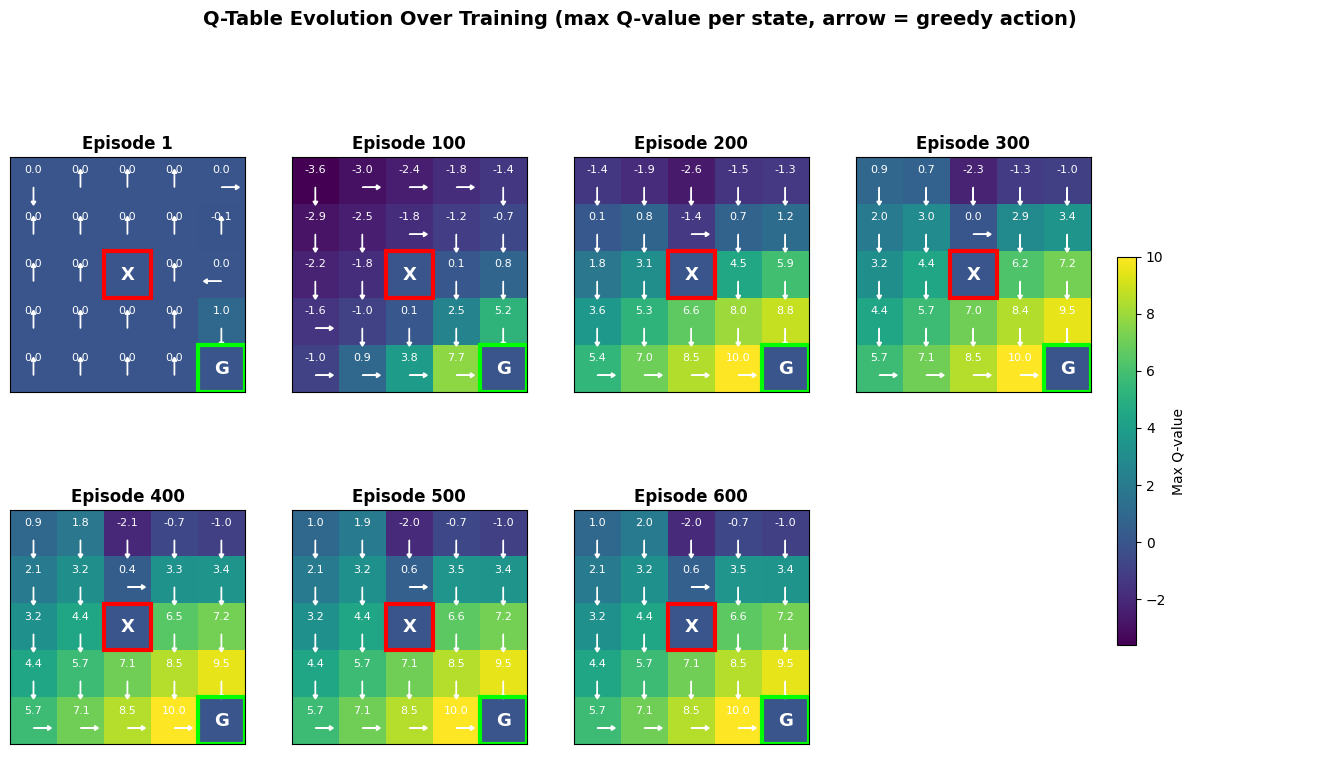

In [2]:
# ----------------------------------------------------------------------------
# 3. Visualize the SEQUENCE of Q-table snapshots (not just the final one)
# ----------------------------------------------------------------------------

def max_q_grid(Q_table):
    return np.max(Q_table, axis=1).reshape(GRID_SIZE, GRID_SIZE)

def best_action_grid(Q_table):
    return np.argmax(Q_table, axis=1).reshape(GRID_SIZE, GRID_SIZE)

n_snapshots = len(snapshots)
n_cols = min(4, n_snapshots)
n_rows = int(np.ceil(n_snapshots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

all_vals = np.concatenate([max_q_grid(q).flatten() for _, q in snapshots])
vmin, vmax = all_vals.min(), all_vals.max()
norm = Normalize(vmin=vmin, vmax=vmax)

arrow_map = {0: (0, 0.3), 1: (0, -0.3), 2: (-0.3, 0), 3: (0.3, 0)}

for i, (ep, q_snap) in enumerate(snapshots):
    ax = axes[i]
    grid_vals = max_q_grid(q_snap)
    best_actions = best_action_grid(q_snap)
    im = ax.imshow(grid_vals, cmap="viridis", norm=norm)

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if (r, c) == GOAL_STATE:
                ax.add_patch(patches.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                                fill=False, edgecolor="lime", linewidth=3))
                ax.text(c, r, "G", ha="center", va="center", color="white",
                        fontsize=13, fontweight="bold")
                continue
            if (r, c) == OBSTACLE_STATE:
                ax.add_patch(patches.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                                fill=False, edgecolor="red", linewidth=3))
                ax.text(c, r, "X", ha="center", va="center", color="white",
                        fontsize=13, fontweight="bold")
                continue

            val = grid_vals[r, c]
            ax.text(c, r - 0.22, f"{val:.1f}", ha="center", va="center",
                    color="white", fontsize=8)
            dx, dy = arrow_map[best_actions[r, c]]
            ax.arrow(c, r + 0.15, dx, -dy, head_width=0.1, head_length=0.08,
                     fc="white", ec="white")

    ax.set_title(f"Episode {ep}", fontsize=12, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

for j in range(n_snapshots, len(axes)):
    axes[j].axis("off")

fig.suptitle("Q-Table Evolution Over Training (max Q-value per state, arrow = greedy action)",
             fontsize=14, fontweight="bold", y=1.02)
fig.colorbar(im, ax=axes[:n_snapshots].tolist(), shrink=0.6, label="Max Q-value", pad=0.02)
plt.show()


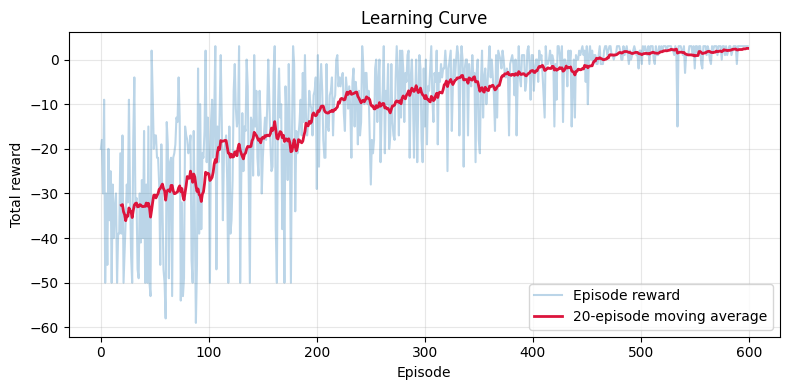

In [3]:
# ----------------------------------------------------------------------------
# 4. Learning curve: episode reward over time
# ----------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 4))
window = 20
smoothed = np.convolve(episode_rewards, np.ones(window) / window, mode="valid")
ax2.plot(episode_rewards, alpha=0.3, label="Episode reward")
ax2.plot(range(window - 1, len(episode_rewards)), smoothed, color="crimson",
         linewidth=2, label=f"{window}-episode moving average")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Total reward")
ax2.set_title("Learning Curve")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Q-Learning on a Grid-World Markov Decision Process

This program implements the Q-learning algorithm to solve a 5x5 grid-world Markov Decision Process. The agent starts in the top-left corner and must reach a goal state in the bottom-right corner while avoiding a penalized obstacle state. At each step, the agent selects an action using an epsilon-greedy policy, receives a reward, and updates its Q-table according to the Bellman update rule.

Rather than reporting only the final Q-table, the program records a snapshot of the entire Q-table at fixed intervals during training (every 100 episodes). Each snapshot is visualized as a heatmap of the maximum Q-value at every state, with an arrow indicating the greedy (highest-value) action at that state. Displaying the snapshots side by side, in sequence, shows how the value information originates at the goal state and gradually propagates outward to the rest of the grid as training progresses, until the Q-table converges to a stable policy.

A learning curve is also plotted, showing the total reward obtained per episode along with a moving average, which illustrates the improvement of the agent's performance over the course of training.

## Discussion

The Q-learning agent successfully learned to navigate the grid-world by iteratively updating its Q-table based on experienced rewards. The sequence of Q-table snapshots clearly shows that learning does not happen uniformly across the state space: value information first appears near the goal state, where a large positive reward is directly received, and then gradually spreads backward to states farther away as the agent's trajectories revisit them.

In the earliest snapshot (episode 1), the Q-table is essentially uninitialized, with all values close to zero, since the agent has not yet experienced any rewards. By the intermediate snapshots, a gradient of increasing Q-values becomes visible, radiating outward from the goal state, and the greedy-action arrows begin to align into a path toward the goal. In the later snapshots, the Q-table has largely converged: the greedy-action arrows form a consistent shortest path from the start state to the goal state while avoiding the obstacle.

This progressive visualization is more informative than examining only the final Q-table, since it reveals the mechanics of temporal-difference learning: the way value estimates bootstrap from neighboring states and gradually converge as sufficient experience accumulates. The learning curve supports this observation, showing that the total reward per episode increases and stabilizes as the number of training episodes grows, consistent with the epsilon-greedy exploration schedule shifting the agent from exploration toward exploitation of its learned policy.

Some variability remains visible even in later episodes, which is expected because a small residual exploration rate (epsilon_end = 0.05) is maintained throughout training, occasionally causing the agent to take a random, suboptimal action.

## Conclusion

This experiment demonstrated the use of Q-learning to solve a grid-world Markov Decision Process and, more importantly, illustrated the value of visualizing the Q-table as a sequence of snapshots rather than only its final, converged form. The sequential visualization showed how value information propagates from a rewarding goal state outward through the state space over the course of training, giving direct visual insight into the convergence behavior of the Q-learning algorithm.

The experiment reinforced key reinforcement learning concepts, including the Bellman update rule, the exploration-exploitation trade-off managed through an epsilon-greedy policy, and the way an agent's action-value estimates improve with accumulated experience. The accompanying learning curve further confirmed that the agent's performance improved and stabilized as training progressed.

Overall, this approach of capturing and displaying the Q-table's evolution provides a much richer and more intuitive understanding of how reinforcement learning agents learn, compared to inspecting only the final result, and could be extended to more complex environments, larger state spaces, or alternative reinforcement learning algorithms such as SARSA or Deep Q-Networks.